In [ ]:
# 📈 Multi-Company Stock Price Prediction using Machine Learning

## Project Overview
This project builds a **generalised** stock closing price predictor that works for **all 501 S&P 500 companies** in the dataset. A single unified model is trained on all companies simultaneously, learning patterns across the entire market.

**Key Design Choices:**
- One model trained on ALL 501 companies (market-wide generalisation)
- Rich feature engineering per-company (moving averages, RSI, MACD, volatility, lag features)
- Multiple models compared (Linear Regression, Ridge, Random Forest, Gradient Boosting)
- Smart prediction interface — user picks a company from a dropdown list, no guessing required

## Pipeline
1. Load & Explore Data
2. Feature Engineering (all 501 companies)
3. EDA — Market Overview
4. Prepare Data for Modelling
5. Train & Compare Models
6. Detailed Evaluation
7. Residual Analysis
8. Feature Importance
9. Prediction Interface (interactive — pick company from list)


In [ ]:
 Step 1 — Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Metrics
from sklearn.metrics import (
    r2_score, mean_squared_error,
    mean_absolute_error, mean_absolute_percentage_error
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

print(' All libraries imported successfully!')
print(' Ready to process 501-company dataset')

 All libraries imported successfully!
 Ready to process 501-company dataset


In [ ]:
Step 2 — Load & Explore Data

In [8]:
# ── Upload / Load ──────────────────────────────────────────────
try:
    from google.colab import files
    uploaded = files.upload()   # Upload prices.csv when prompted
    df_raw = pd.read_csv('prices.csv')
except Exception:
    df_raw = pd.read_csv('prices.csv')

# Parse dates (handles mixed formats in the file)
df_raw['date'] = pd.to_datetime(df_raw['date'], format='mixed')

print('=== DATASET OVERVIEW ===')
print(f'Total rows        : {len(df_raw):,}')
print(f'Total companies   : {df_raw["symbol"].nunique()}')
print(f'Date range        : {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Columns           : {df_raw.columns.tolist()}')
print(f'\nMissing values:\n{df_raw.isnull().sum()}')
print(f'\nSample rows:')
df_raw.head()

Saving prices.csv to prices.csv
=== DATASET OVERVIEW ===
Total rows        : 851,264
Total companies   : 501
Date range        : 2010-01-04 → 2016-12-30
Columns           : ['date', 'symbol', 'open', 'close', 'low', 'high', 'volume']

Missing values:
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64

Sample rows:


,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.4300,125.8400,122.3100,126.2500,2163600.0000
1,2016-01-06,WLTW,125.2400,119.9800,119.9400,125.5400,2386400.0000
2,2016-01-07,WLTW,116.3800,114.9500,114.9300,119.7400,2489500.0000
3,2016-01-08,WLTW,115.4800,116.6200,113.5000,117.4400,2006300.0000
4,2016-01-11,WLTW,117.0100,114.9700,114.0900,117.3300,1408600.0000


In [9]:
# Basic info
print('=== DATASET INFO ===')
df_raw.info()

print('\n=== MISSING VALUES ===')
print(df_raw.isnull().sum())

print('\n=== UNIQUE SYMBOLS ===')
print(df_raw['symbol'].unique())

print('Total symbols:', df_raw['symbol'].nunique())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    851264 non-null  datetime64[ns]
 1   symbol  851264 non-null  object        
 2   open    851264 non-null  float64       
 3   close   851264 non-null  float64       
 4   low     851264 non-null  float64       
 5   high    851264 non-null  float64       
 6   volume  851264 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 45.5+ MB

=== MISSING VALUES ===
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64

=== UNIQUE SYMBOLS ===
['WLTW' 'A' 'AAL' 'AAP' 'AAPL' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADS' 'ADSK' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG' 'AIZ' 'AJG' 'AKAM'
 'ALB' 'ALK' 'ALL' 'ALXN' 'AMAT' 'AME' 'AMG' 'AMGN' 'AMP' 'AMT' 'AMZN'
 'AN' 'ANTM' 'AON' 'APA' 'A

In [10]:
# Records per company summary
recs = df_raw.groupby('symbol').size()
print('Records per company:')
print(f'  Min    : {recs.min()}')
print(f'  Max    : {recs.max()}')
print(f'  Median : {recs.median()}')
print(f'  Mean   : {recs.mean():.1f}')

print(f'\n\nAll {df_raw["symbol"].nunique()} company symbols:')
symbols_list = sorted(df_raw['symbol'].unique())
for i in range(0, len(symbols_list), 20):
    print('  ', ', '.join(symbols_list[i:i+20]))

Records per company:
  Min    : 126
  Max    : 1762
  Median : 1762.0
  Mean   : 1699.1


All 501 company symbols:
   A, AAL, AAP, AAPL, ABBV, ABC, ABT, ACN, ADBE, ADI, ADM, ADP, ADS, ADSK, AEE, AEP, AES, AET, AFL, AGN
   AIG, AIV, AIZ, AJG, AKAM, ALB, ALK, ALL, ALLE, ALXN, AMAT, AME, AMG, AMGN, AMP, AMT, AMZN, AN, ANTM, AON
   APA, APC, APD, APH, ARNC, ATVI, AVB, AVGO, AVY, AWK, AXP, AYI, AZO, BA, BAC, BAX, BBBY, BBT, BBY, BCR
   BDX, BEN, BHI, BIIB, BK, BLK, BLL, BMY, BSX, BWA, BXP, C, CA, CAG, CAH, CAT, CB, CBG, CBS, CCI
   CCL, CELG, CERN, CF, CFG, CHD, CHK, CHRW, CHTR, CI, CINF, CL, CLX, CMA, CMCSA, CME, CMG, CMI, CMS, CNC
   CNP, COF, COG, COH, COL, COO, COP, COST, COTY, CPB, CRM, CSCO, CSRA, CSX, CTAS, CTL, CTSH, CTXS, CVS, CVX
   CXO, D, DAL, DD, DE, DFS, DG, DGX, DHI, DHR, DIS, DISCA, DISCK, DLPH, DLR, DLTR, DNB, DOV, DOW, DPS
   DRI, DTE, DUK, DVA, DVN, EA, EBAY, ECL, ED, EFX, EIX, EL, EMN, EMR, ENDP, EOG, EQIX, EQR, EQT, ES
   ESRX, ESS, ETFC, ETN, ETR, EVHC, EW, EXC, EXPD, 

In [ ]:
 Step 3 — Feature Engineering (All Companies)

Features are computed **per company** using `groupby`, so no data leaks between companies.

In [12]:
def engineer_features(group):
    """
    Compute technical indicators for a single company's price series.
    Called via groupby — each group is one company sorted by date.
    """
    g = group.sort_values('date').copy()

    # ── Moving Averages ────────────────────────────────────────
    g['MA_5']  = g['close'].rolling(5).mean()
    g['MA_10'] = g['close'].rolling(10).mean()
    g['MA_20'] = g['close'].rolling(20).mean()
    g['MA_50'] = g['close'].rolling(50).mean()

    # ── Exponential Moving Averages & MACD ────────────────────
    g['EMA_12'] = g['close'].ewm(span=12, adjust=False).mean()
    g['EMA_26'] = g['close'].ewm(span=26, adjust=False).mean()
    g['MACD']   = g['EMA_12'] - g['EMA_26']

    # ── Volatility ────────────────────────────────────────────
    g['volatility_20'] = g['close'].rolling(20).std()

    # ── Price-based features ──────────────────────────────────
    g['daily_range']    = g['high'] - g['low']
    g['close_open_diff']= g['close'] - g['open']
    g['hl_pct']         = (g['high'] - g['low']) / g['open'] * 100
    g['co_pct']         = (g['close'] - g['open']) / g['open'] * 100

    # ── Volume ───────────────────────────────────────────────
    g['vol_MA_20'] = g['volume'].rolling(20).mean()
    g['vol_ratio'] = g['volume'] / g['vol_MA_20']   # volume spike indicator

    # ── RSI (14-day) ─────────────────────────────────────────
    delta    = g['close'].diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs       = avg_gain / avg_loss
    g['RSI_14'] = 100 - (100 / (1 + rs))

    # ── Bollinger Band Width ─────────────────────────────────
    g['BB_upper'] = g['MA_20'] + 2 * g['volatility_20']
    g['BB_lower'] = g['MA_20'] - 2 * g['volatility_20']
    g['BB_width'] = g['BB_upper'] - g['BB_lower']
    g['BB_pct']   = (g['close'] - g['BB_lower']) / (g['BB_upper'] - g['BB_lower'])  # 0-1 band position

    # ── Lag Features (previous N days close) ────────────────
    for lag in [1, 2, 3, 5, 10]:
        g[f'close_lag{lag}'] = g['close'].shift(lag)

    # ── Price momentum (rate of change) ─────────────────────
    g['roc_5']  = g['close'].pct_change(5)  * 100
    g['roc_10'] = g['close'].pct_change(10) * 100

    return g


print('  Engineering features for all 501 companies...')
df = (df_raw
      .groupby('symbol', group_keys=False)
      .apply(engineer_features)
      .dropna()
      .reset_index(drop=True))

print(f'  Feature Engineering Done!')
print(f'   Rows after feature engineering : {len(df):,}')
print(f'   Total features                 : {df.shape[1]}')
print(f'   Feature columns                : {[c for c in df.columns if c not in ["date","symbol"]]}')

  Engineering features for all 501 companies...
  Feature Engineering Done!
   Rows after feature engineering : 826,715
   Total features                 : 33
   Feature columns                : ['open', 'close', 'low', 'high', 'volume', 'MA_5', 'MA_10', 'MA_20', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'volatility_20', 'daily_range', 'close_open_diff', 'hl_pct', 'co_pct', 'vol_MA_20', 'vol_ratio', 'RSI_14', 'BB_upper', 'BB_lower', 'BB_width', 'BB_pct', 'close_lag1', 'close_lag2', 'close_lag3', 'close_lag5', 'close_lag10', 'roc_5', 'roc_10']


In [13]:
df['target'] = df.groupby('symbol')['close'].shift(-1)

In [14]:
df = df.dropna()

In [ ]:
Step 4 — Exploratory Data Analysis (EDA)

In [15]:
# ── Market-level statistics ───────────────────────────────────
print('=== MARKET-WIDE STATISTICS ===')
print(df[['open','high','low','close','volume']].describe().round(2))

=== MARKET-WIDE STATISTICS ===
             open        high         low       close         volume
count 826214.0000 826214.0000 826214.0000 826214.0000    826214.0000
mean      71.5700     72.2800     70.8500     71.5900   5358279.3800
std       84.4100     85.1900     83.5900     84.4100  12313691.8400
min        0.8500      0.8800      0.8300      0.8600         0.0000
25%       34.2100     34.5600     33.8500     34.2200   1215400.0000
50%       53.3600     53.8900     52.8200     53.3900   2459200.0000
75%       80.5900     81.3500     79.8300     80.6200   5181900.0000
max     1584.4400   1600.9300   1549.9400   1578.1300 859643400.0000


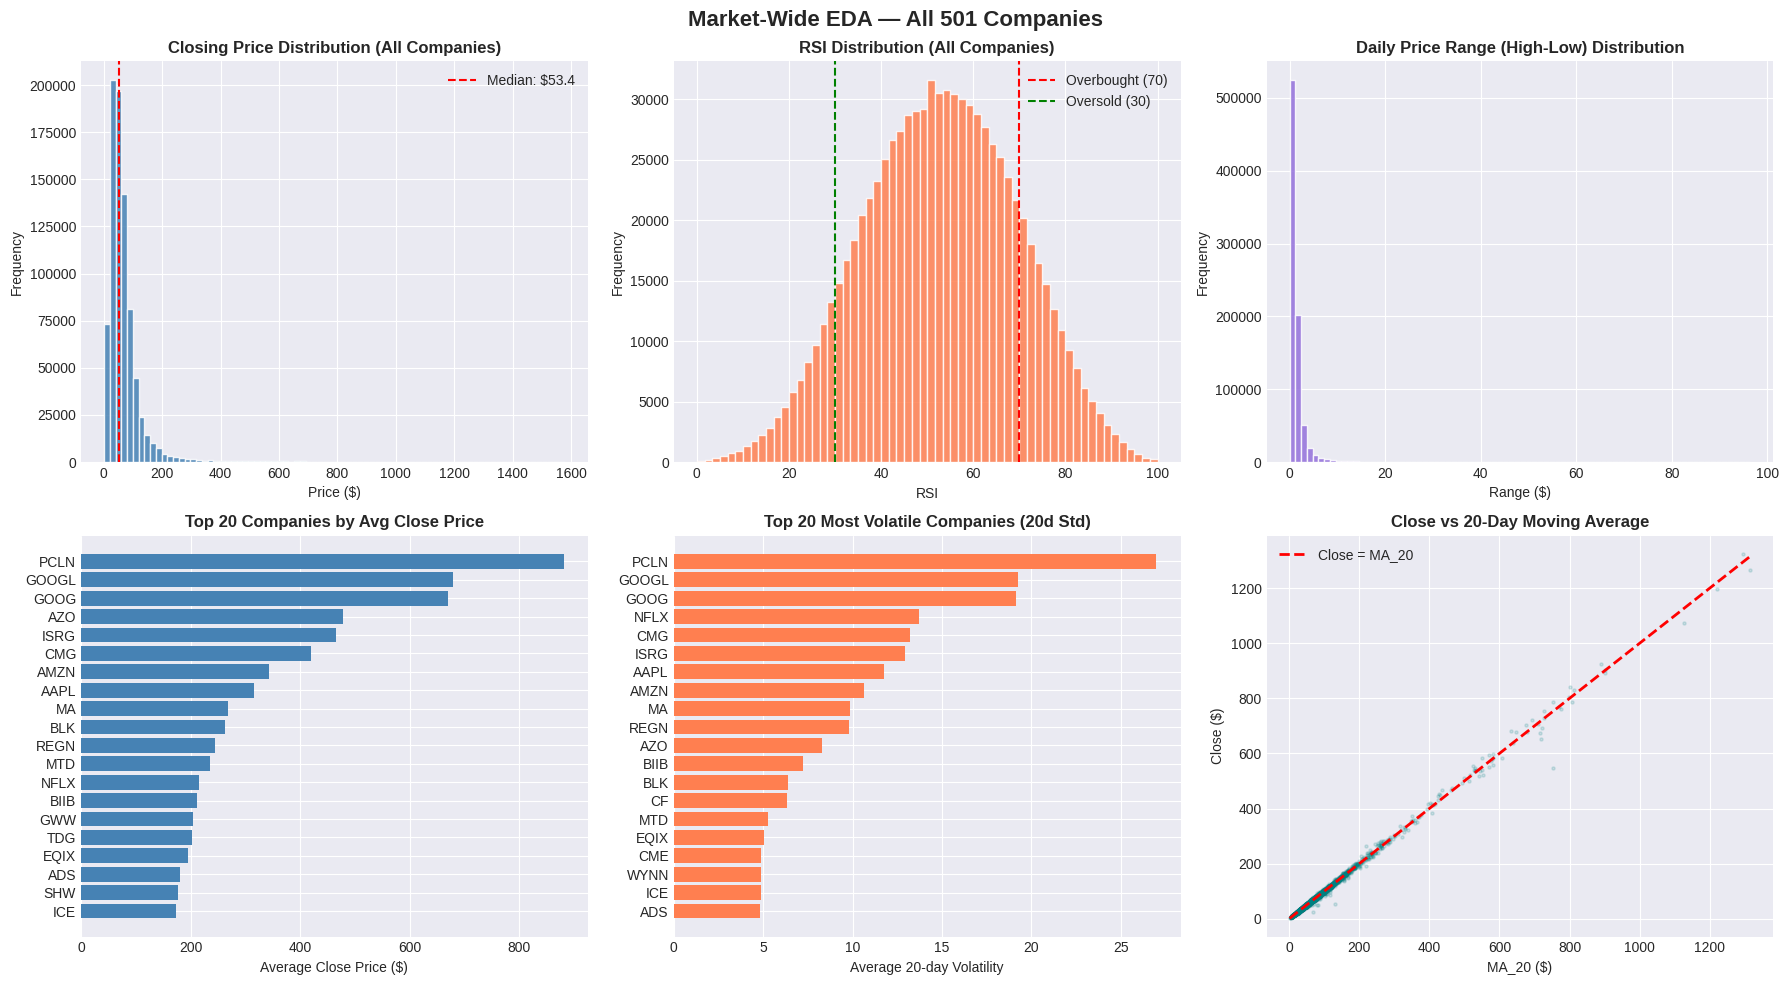

In [16]:
# ── Plot 1: Price distribution across all companies ──────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Market-Wide EDA — All 501 Companies', fontsize=16, fontweight='bold')

# Closing price distribution
axes[0,0].hist(df['close'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Closing Price Distribution (All Companies)', fontweight='bold')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['close'].median(), color='red', linestyle='--', label=f'Median: ${df["close"].median():.1f}')
axes[0,0].legend()

# RSI distribution
axes[0,1].hist(df['RSI_14'], bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].axvline(70, color='red', linestyle='--', label='Overbought (70)')
axes[0,1].axvline(30, color='green', linestyle='--', label='Oversold (30)')
axes[0,1].set_title('RSI Distribution (All Companies)', fontweight='bold')
axes[0,1].set_xlabel('RSI')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Daily range distribution
axes[0,2].hist(df['daily_range'], bins=80, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Daily Price Range (High-Low) Distribution', fontweight='bold')
axes[0,2].set_xlabel('Range ($)')
axes[0,2].set_ylabel('Frequency')

# Average closing price per company (top 20 & bottom 20)
avg_price = df.groupby('symbol')['close'].mean().sort_values(ascending=False)
top20 = avg_price.head(20)
axes[1,0].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
axes[1,0].set_title('Top 20 Companies by Avg Close Price', fontweight='bold')
axes[1,0].set_xlabel('Average Close Price ($)')

# Volatility comparison (top 20 most volatile)
avg_vol = df.groupby('symbol')['volatility_20'].mean().sort_values(ascending=False)
top20v = avg_vol.head(20)
axes[1,1].barh(top20v.index[::-1], top20v.values[::-1], color='coral')
axes[1,1].set_title('Top 20 Most Volatile Companies (20d Std)', fontweight='bold')
axes[1,1].set_xlabel('Average 20-day Volatility')

# Close vs MA_20 scatter (sample)
sample = df.sample(5000, random_state=42)
axes[1,2].scatter(sample['MA_20'], sample['close'], alpha=0.15, s=5, color='teal')
lims = [sample['MA_20'].min(), sample['MA_20'].max()]
axes[1,2].plot(lims, lims, 'r--', linewidth=2, label='Close = MA_20')
axes[1,2].set_title('Close vs 20-Day Moving Average', fontweight='bold')
axes[1,2].set_xlabel('MA_20 ($)')
axes[1,2].set_ylabel('Close ($)')
axes[1,2].legend()

plt.tight_layout()
plt.show()

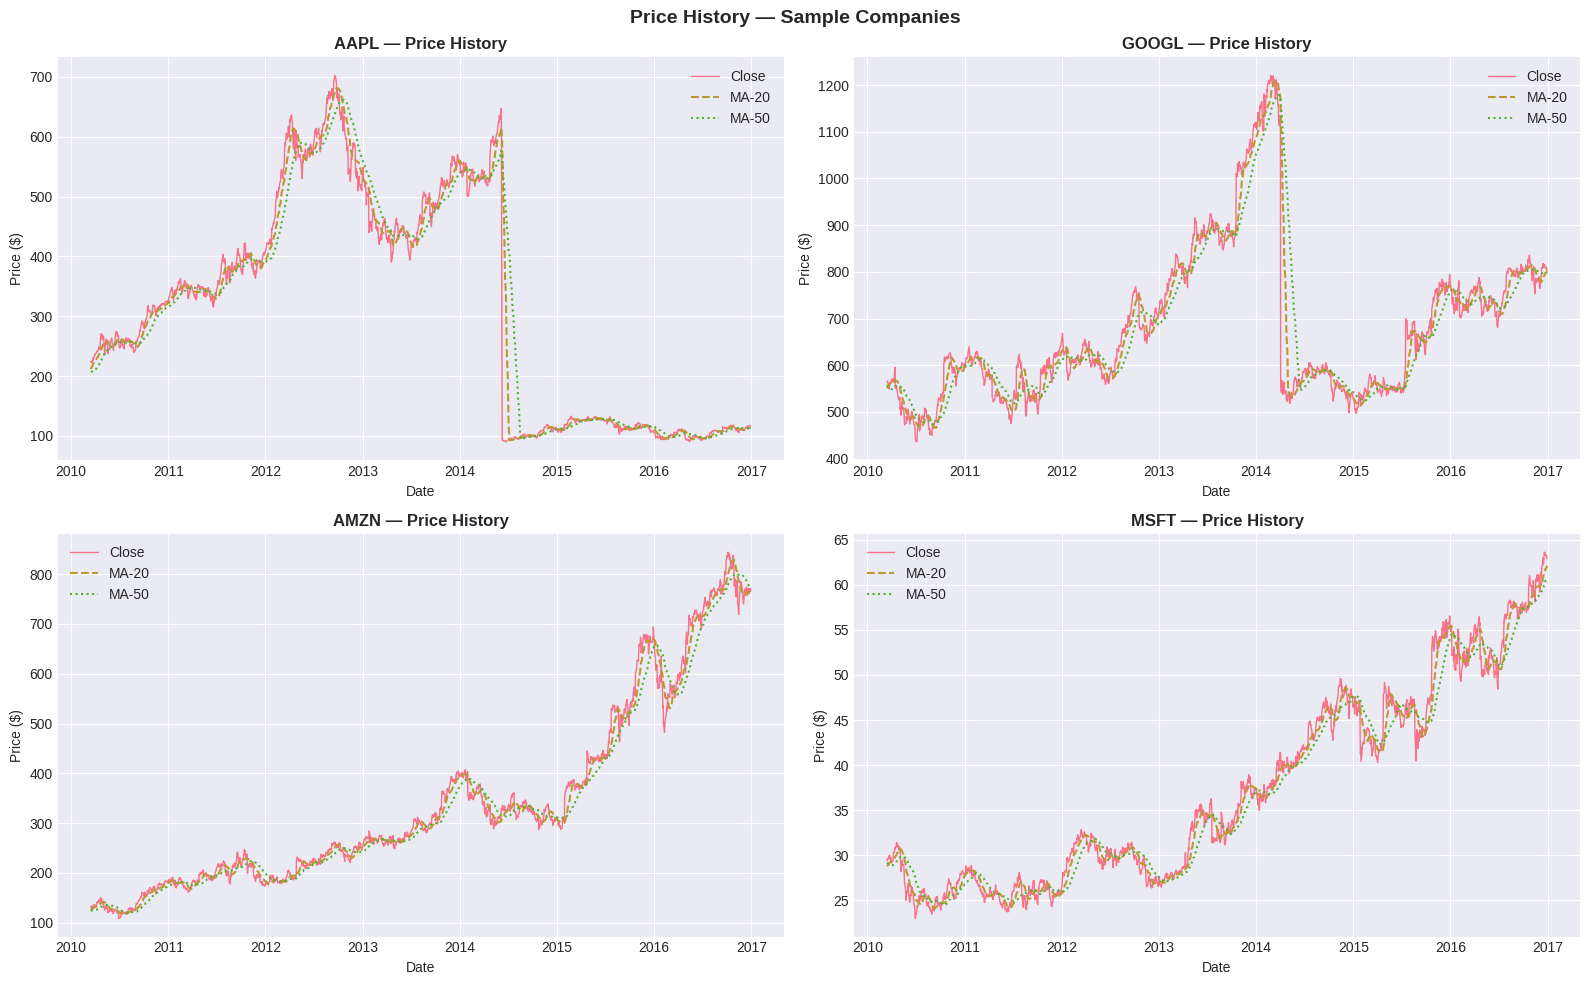

In [17]:
# ── Sample of 4 companies price history ──────────────────────
sample_companies = ['AAPL', 'GOOGL', 'AMZN', 'MSFT']
# Fall back gracefully if some symbols not in dataset
sample_companies = [s for s in sample_companies if s in df['symbol'].unique()]
if len(sample_companies) < 4:
    sample_companies = sorted(df['symbol'].unique())[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Price History — Sample Companies', fontsize=14, fontweight='bold')

for ax, sym in zip(axes.flat, sample_companies):
    d = df[df['symbol'] == sym].sort_values('date')
    ax.plot(d['date'], d['close'], label='Close', linewidth=1)
    ax.plot(d['date'], d['MA_20'], label='MA-20', linewidth=1.5, linestyle='--')
    ax.plot(d['date'], d['MA_50'], label='MA-50', linewidth=1.5, linestyle=':')
    ax.set_title(f'{sym} — Price History', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()

plt.tight_layout()
plt.show()

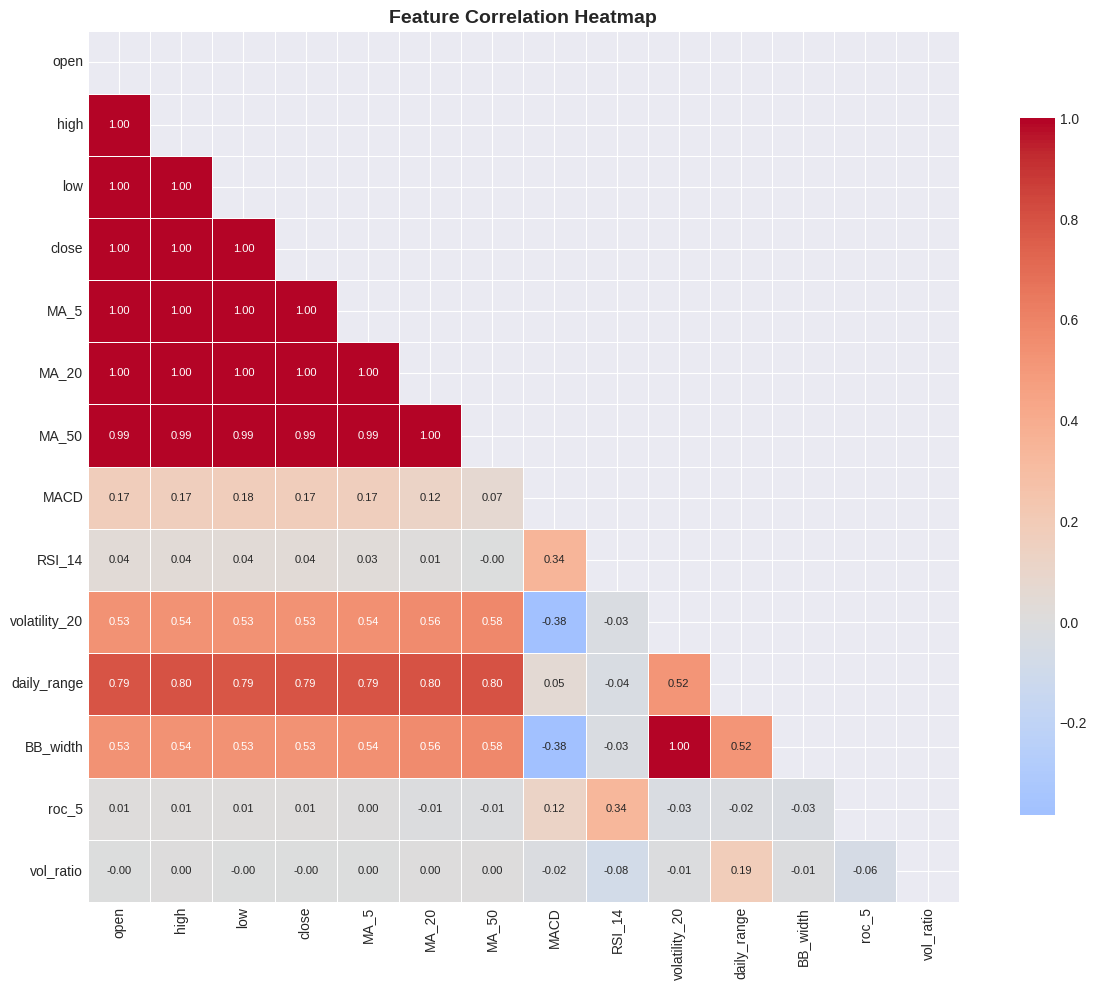

In [18]:
# ── Correlation heatmap of features ──────────────────────────
corr_cols = ['open','high','low','close','MA_5','MA_20','MA_50',
             'MACD','RSI_14','volatility_20','daily_range',
             'BB_width','roc_5','vol_ratio']

plt.figure(figsize=(13, 10))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
 Step 5 — Prepare Data for Modelling

Strategy: Train on data from all companies combined. A **time-based split** is used — the last 20% of calendar time is held out as the test set. This prevents future data leaking into training.

In [19]:
FEATURE_COLS = [
    'open',
    'high',
    'low',
    'volume',
    'close',
    'MACD',
    'volatility_20',
    'daily_range',
    'hl_pct',
    'co_pct',
    'vol_MA_20',
    'vol_ratio',
    'RSI_14',
    'BB_width',
    'BB_pct',
    'roc_5',
    'roc_10'
]
df['target'] = df.groupby('symbol')['close'].shift(-1)
df = df.dropna(subset=['target'])
TARGET_COL = 'target'

# Time-based split: use last 20% of date range as test
cutoff_date = df['date'].quantile(0.80)
train_df = df[df['date'] <= cutoff_date]
test_df  = df[df['date'] >  cutoff_date]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f'Cut-off date       : {cutoff_date.date()}')
print(f'Training samples   : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)')
print(f'Test samples       : {len(X_test):,}  ({len(X_test)/len(df)*100:.1f}%)')
print(f'Number of features : {len(FEATURE_COLS)}')
print(f'\nFeatures:')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {f}')

Cut-off date       : 2015-09-08
Training samples   : 660,948  (80.0%)
Test samples       : 164,765  (20.0%)
Number of features : 17

Features:
   1. open
   2. high
   3. low
   4. volume
   5. close
   6. MACD
   7. volatility_20
   8. daily_range
   9. hl_pct
  10. co_pct
  11. vol_MA_20
  12. vol_ratio
  13. RSI_14
  14. BB_width
  15. BB_pct
  16. roc_5
  17. roc_10


In [20]:
# Combine to clean properly
train_df = train_df.dropna()
test_df  = test_df.dropna()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

In [21]:
print("Train NaN:", X_train.isnull().sum().sum(), y_train.isnull().sum())
print("Test NaN :", X_test.isnull().sum().sum(), y_test.isnull().sum())

Train NaN: 0 0
Test NaN : 0 0


In [22]:
df = df.sample(20000, random_state=42)

In [ ]:
Step 6 — Train & Compare Models

In [23]:
MODELS = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Lasso Regression'   : Lasso(alpha=0.01, max_iter=5000),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=10, random_state=42),

    # ⚡ Reduced Random Forest
    'Random Forest'      : RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        n_jobs=-1,
        random_state=42
    ),  # ✅ <-- THIS COMMA WAS MISSING

    # ⚡ Reduced Gradient Boosting
    'Gradient Boosting'  : GradientBoostingRegressor(
        n_estimators=50,
        max_depth=3,
        random_state=42
    )
}

results   = []
trained   = {}   # stores (model, y_pred) pairs

print(f'{"Model":<22} | {"R²":>8} | {"MAE":>8} | {"RMSE":>8} | {"MAPE %":>8}')
print('-' * 65)

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({'Model': name, 'R² Score': r2, 'MAE ($)': mae,
                    'RMSE ($)': rmse, 'MAPE (%)': mape})
    trained[name] = (model, y_pred)
    print(f'{name:<22} | {r2:>8.4f} | {mae:>8.2f} | {rmse:>8.2f} | {mape:>8.2f}')

results_df = (pd.DataFrame(results)
              .set_index('Model')
              .sort_values('R² Score', ascending=False))

print('\n=== RANKED MODEL SUMMARY ===')
results_df.round(4)

Model                  |       R² |      MAE |     RMSE |   MAPE %
-----------------------------------------------------------------
Linear Regression      |   0.9995 |     0.99 |     2.29 |     1.28
Ridge Regression       |   0.9995 |     0.99 |     2.29 |     1.28
Lasso Regression       |   0.9995 |     1.03 |     2.38 |     1.46
Decision Tree          |   0.9603 |     1.71 |    20.51 |     1.42
Random Forest          |   0.9942 |     1.30 |     7.84 |     1.32
Gradient Boosting      |   0.9973 |     1.45 |     5.37 |     2.13

=== RANKED MODEL SUMMARY ===


,R² Score,MAE ($),RMSE ($),MAPE (%)
Model,,,,
Ridge Regression,0.9995,0.9857,2.2912,1.2770
Linear Regression,0.9995,0.9857,2.2912,1.2770
Lasso Regression,0.9995,1.0288,2.3820,1.4613
Gradient Boosting,0.9973,1.4503,5.3742,2.1253
Random Forest,0.9942,1.3010,7.8399,1.3176
Decision Tree,0.9603,1.7095,20.5118,1.4211


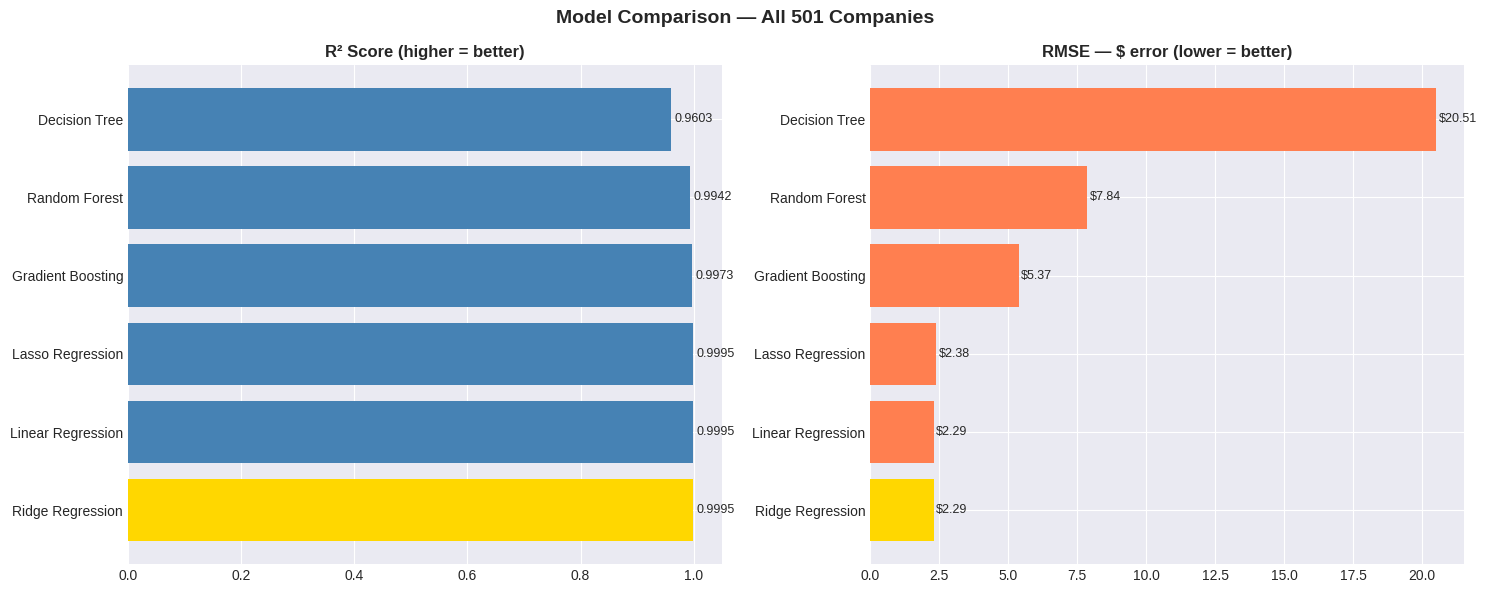

 Best model: Ridge Regression  (R² = 0.9995)


In [25]:
# ── Model comparison chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison — All 501 Companies', fontsize=14, fontweight='bold')

df_plot = results_df.reset_index()

# R2
colors_r2 = ['gold' if i == 0 else 'steelblue' for i in range(len(df_plot))]
bars = axes[0].barh(df_plot['Model'], df_plot['R² Score'], color=colors_r2)
axes[0].set_title('R² Score (higher = better)', fontweight='bold')
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, df_plot['R² Score']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE
colors_rm = ['gold' if i == 0 else 'coral'
             for i in range(len(df_plot))]
bars2 = axes[1].barh(df_plot['Model'], df_plot['RMSE ($)'], color=colors_rm)
axes[1].set_title('RMSE — $ error (lower = better)', fontweight='bold')
for bar, val in zip(bars2, df_plot['RMSE ($)']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

best_name = results_df.index[0]
print(f' Best model: {best_name}  (R² = {results_df.loc[best_name, "R² Score"]:.4f})')

In [ ]:
 Step 7 — Detailed Evaluation (Linear Regression + Best Model)

In [26]:
def print_metrics(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print(f'\n=== {name.upper()} ===')
    print(f'  R² Score         : {r2:.6f}')
    print(f'  MAE              : ${mae:.4f}')
    print(f'  MSE              : {mse:.4f}')
    print(f'  RMSE             : ${rmse:.4f}')
    print(f'  MAPE             : {mape:.4f}%')
    print(f'  Pearson r        : {corr:.6f}')
    print(f'  Accuracy proxy   : {(1 - mape/100)*100:.2f}%   (100 - MAPE)')


lr_model, lr_pred = trained['Linear Regression']
best_model, best_pred = trained[best_name]

print_metrics('Linear Regression', y_test, lr_pred)
if best_name != 'Linear Regression':
    print_metrics(best_name, y_test, best_pred)


=== LINEAR REGRESSION ===
  R² Score         : 0.999505
  MAE              : $0.9857
  MSE              : 5.2497
  RMSE             : $2.2912
  MAPE             : 1.2770%
  Pearson r        : 0.999752
  Accuracy proxy   : 98.72%   (100 - MAPE)

=== RIDGE REGRESSION ===
  R² Score         : 0.999505
  MAE              : $0.9857
  MSE              : 5.2497
  RMSE             : $2.2912
  MAPE             : 1.2770%
  Pearson r        : 0.999752
  Accuracy proxy   : 98.72%   (100 - MAPE)


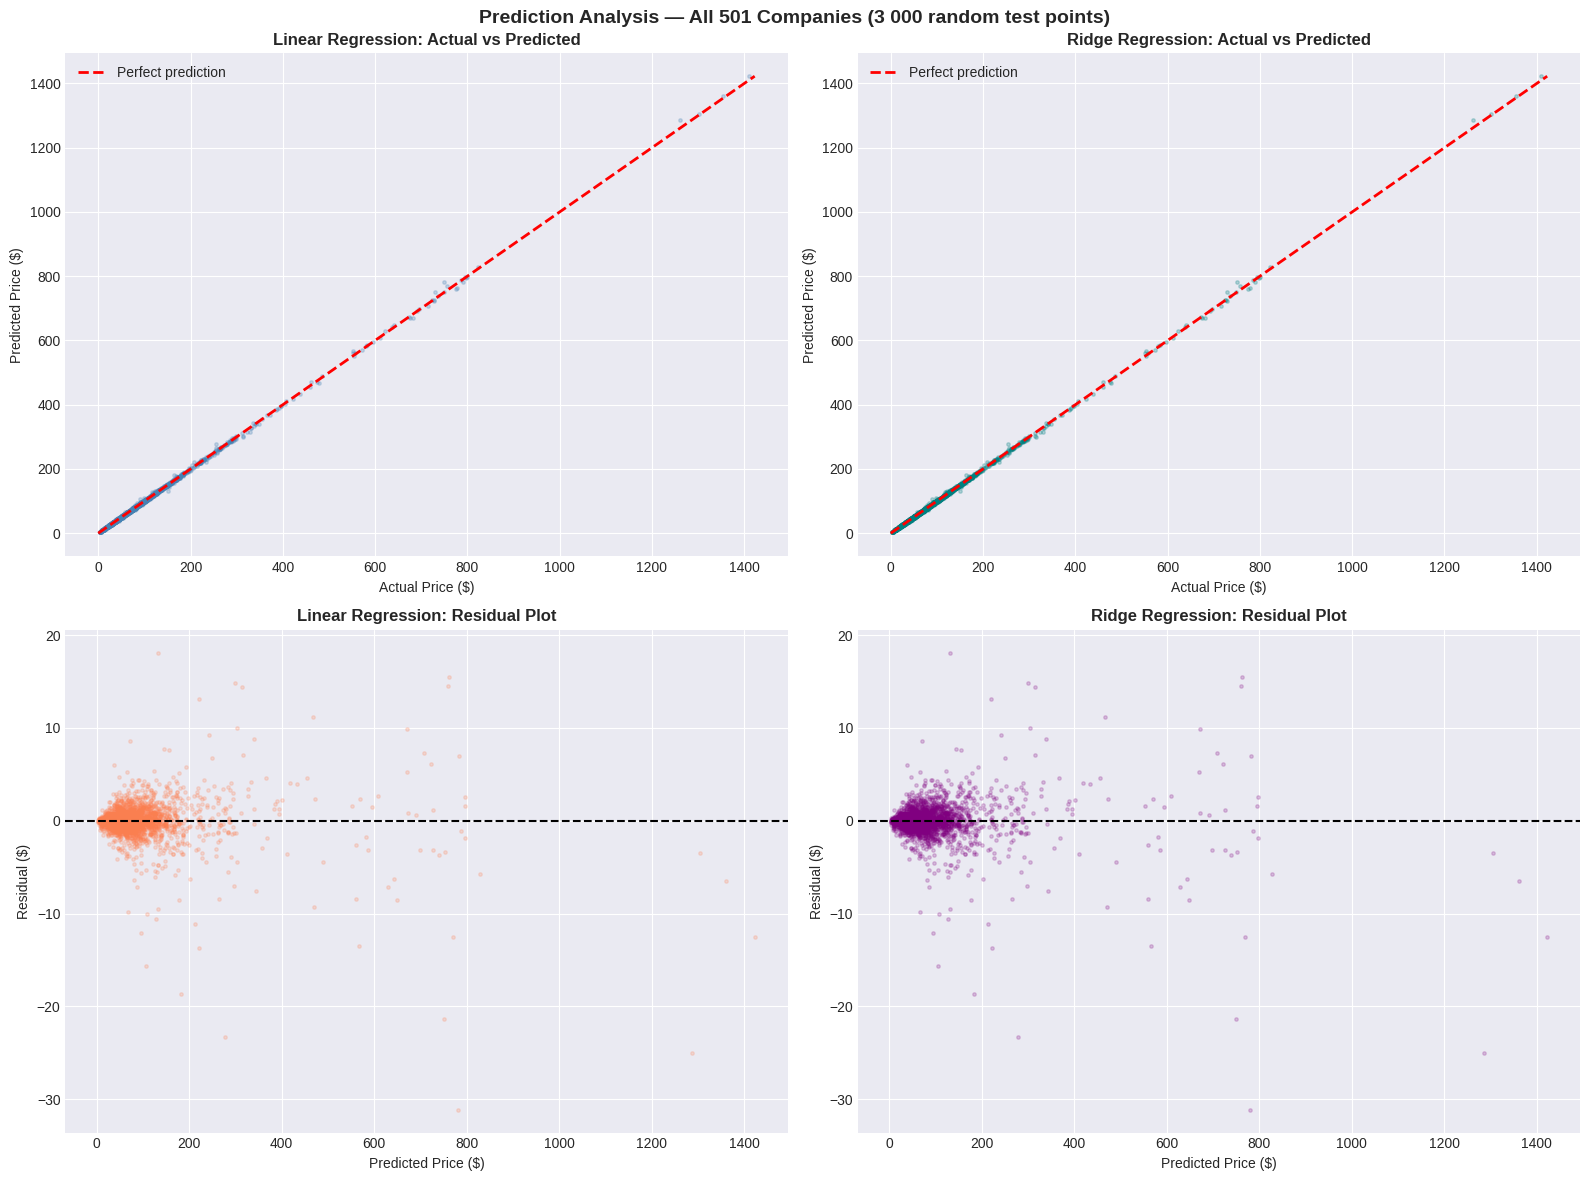

In [27]:
# ── Actual vs Predicted plots ─────────────────────────────────
# Sample 3000 points for clearer scatter plots
idx = np.random.choice(len(y_test), size=3000, replace=False)
yt_s  = y_test.values[idx]
lr_s  = lr_pred[idx]
best_s = best_pred[idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prediction Analysis — All 501 Companies (3 000 random test points)',
             fontsize=14, fontweight='bold')

# 1. LR scatter
axes[0,0].scatter(yt_s, lr_s, alpha=0.25, s=6, color='steelblue')
lim = [0, max(yt_s.max(), lr_s.max())]
axes[0,0].plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
axes[0,0].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[0,0].set_xlabel('Actual Price ($)')
axes[0,0].set_ylabel('Predicted Price ($)')
axes[0,0].legend()

# 2. Best model scatter
axes[0,1].scatter(yt_s, best_s, alpha=0.25, s=6, color='teal')
lim2 = [0, max(yt_s.max(), best_s.max())]
axes[0,1].plot(lim2, lim2, 'r--', linewidth=2, label='Perfect prediction')
axes[0,1].set_title(f'{best_name}: Actual vs Predicted', fontweight='bold')
axes[0,1].set_xlabel('Actual Price ($)')
axes[0,1].set_ylabel('Predicted Price ($)')
axes[0,1].legend()

# 3. LR residuals vs predicted
lr_res = yt_s - lr_s
axes[1,0].scatter(lr_s, lr_res, alpha=0.2, s=6, color='coral')
axes[1,0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1,0].set_title('Linear Regression: Residual Plot', fontweight='bold')
axes[1,0].set_xlabel('Predicted Price ($)')
axes[1,0].set_ylabel('Residual ($)')

# 4. Best model residuals
best_res = yt_s - best_s
axes[1,1].scatter(best_s, best_res, alpha=0.2, s=6, color='purple')
axes[1,1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1,1].set_title(f'{best_name}: Residual Plot', fontweight='bold')
axes[1,1].set_xlabel('Predicted Price ($)')
axes[1,1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.show()

In [ ]:
 Step 8 — Residual Distribution Analysis

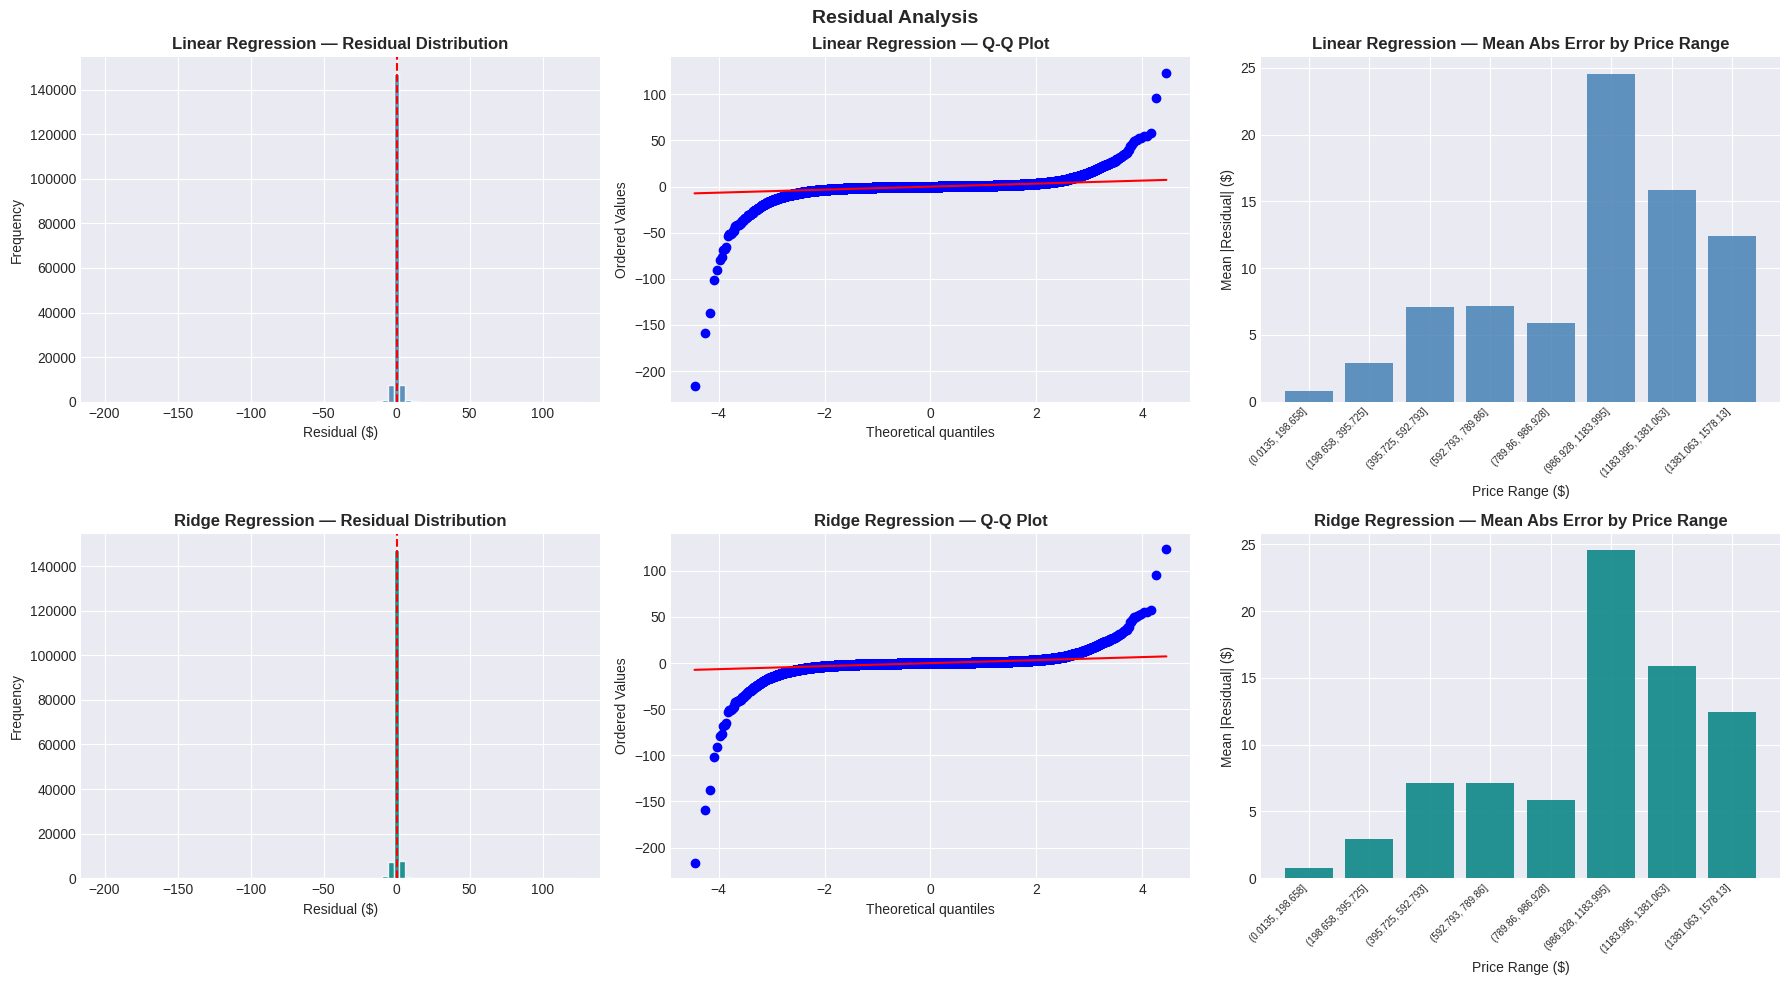

Linear Regression Residuals:
  Mean    : -0.0030
  Std Dev : 2.2912
  Skew    : -8.9923

Ridge Regression Residuals:
  Mean    : -0.0030
  Std Dev : 2.2912
  Skew    : -8.9923


In [28]:
residuals_lr   = y_test.values - lr_pred
residuals_best = y_test.values - best_pred

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

for row, (res, label, col) in enumerate([
    (residuals_lr,   'Linear Regression', 'steelblue'),
    (residuals_best, best_name,           'teal')
]):
    # Histogram
    axes[row,0].hist(np.clip(res, -200, 200), bins=80,
                     color=col, edgecolor='white', alpha=0.85)
    axes[row,0].axvline(0, color='red', linestyle='--')
    axes[row,0].set_title(f'{label} — Residual Distribution', fontweight='bold')
    axes[row,0].set_xlabel('Residual ($)')
    axes[row,0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(res, dist='norm', plot=axes[row,1])
    axes[row,1].set_title(f'{label} — Q-Q Plot', fontweight='bold')

    # Error by price range (binned)
    temp = pd.DataFrame({'actual': y_test.values, 'residual': np.abs(res)})
    temp['price_bin'] = pd.cut(temp['actual'], bins=8)
    bin_err = temp.groupby('price_bin', observed=True)['residual'].mean()
    axes[row,2].bar(range(len(bin_err)), bin_err.values, color=col, alpha=0.85)
    axes[row,2].set_xticks(range(len(bin_err)))
    axes[row,2].set_xticklabels([str(b) for b in bin_err.index],
                                 rotation=45, ha='right', fontsize=7)
    axes[row,2].set_title(f'{label} — Mean Abs Error by Price Range', fontweight='bold')
    axes[row,2].set_xlabel('Price Range ($)')
    axes[row,2].set_ylabel('Mean |Residual| ($)')

plt.tight_layout()
plt.show()

print('Linear Regression Residuals:')
print(f'  Mean    : {residuals_lr.mean():.4f}')
print(f'  Std Dev : {residuals_lr.std():.4f}')
print(f'  Skew    : {pd.Series(residuals_lr).skew():.4f}')

print(f'\n{best_name} Residuals:')
print(f'  Mean    : {residuals_best.mean():.4f}')
print(f'  Std Dev : {residuals_best.std():.4f}')
print(f'  Skew    : {pd.Series(residuals_best).skew():.4f}')

In [ ]:
 Step 9 — Feature Importance

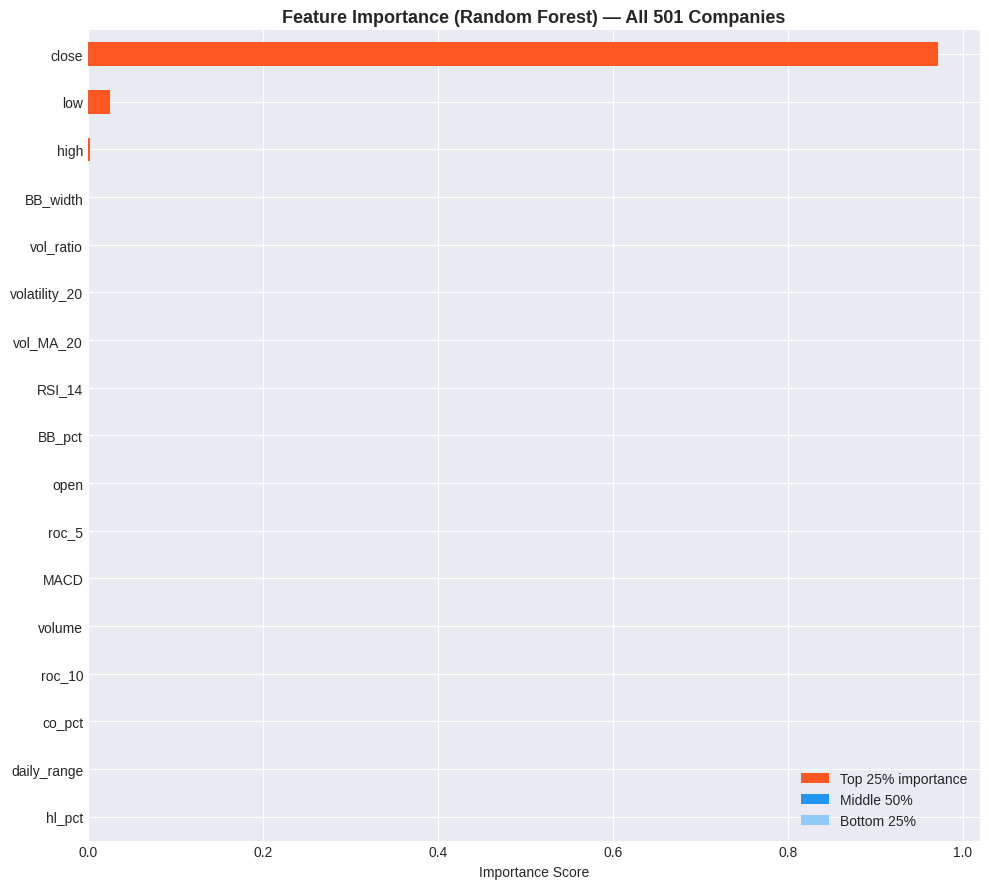

Top 10 Features:
close           0.9711
low             0.0256
high            0.0028
BB_width        0.0001
vol_ratio       0.0001
volatility_20   0.0000
vol_MA_20       0.0000
RSI_14          0.0000
BB_pct          0.0000
open            0.0000


In [29]:
rf_model = trained['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_,
                         index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#FF5722' if v >= importances.quantile(0.75) else
          '#2196F3' if v >= importances.quantile(0.25) else
          '#90CAF9'
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance (Random Forest) — All 501 Companies',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF5722', label='Top 25% importance'),
    Patch(facecolor='#2196F3', label='Middle 50%'),
    Patch(facecolor='#90CAF9', label='Bottom 25%'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 Features:')
print(importances.sort_values(ascending=False).head(10).to_string())

In [ ]:
 Step 10 — Cross-Validation

In [30]:
# Using a smaller stratified sample for CV speed (still 50k+ rows)
cv_sample = df.sample(n=min(60000, len(df)), random_state=42)
X_cv = cv_sample[FEATURE_COLS]
y_cv = cv_sample[TARGET_COL]

tscv = TimeSeriesSplit(n_splits=5)

print('=== 5-Fold Time-Series Cross-Validation (60k sample) ===')
print(f'{"Model":<22} | {"Mean R²":>9} | {"Std R²":>8} | {"Mean RMSE":>10}')
print('-' * 60)

for name, (model, _) in trained.items():
    cv_r2  = cross_val_score(model, X_cv, y_cv, cv=tscv, scoring='r2', n_jobs=-1)
    cv_mse = cross_val_score(model, X_cv, y_cv, cv=tscv,
                              scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_mse)
    print(f'{name:<22} | {cv_r2.mean():>9.4f} | {cv_r2.std():>8.4f} | {cv_rmse.mean():>10.4f}')

=== 5-Fold Time-Series Cross-Validation (60k sample) ===
Model                  |   Mean R² |   Std R² |  Mean RMSE
------------------------------------------------------------
Linear Regression      |    0.9994 |   0.0002 |     2.1117
Ridge Regression       |    0.9994 |   0.0002 |     2.1117
Lasso Regression       |    0.9994 |   0.0002 |     2.1551
Decision Tree          |    0.9964 |   0.0023 |     5.0825
Random Forest          |    0.9980 |   0.0010 |     3.8392
Gradient Boosting      |    0.9977 |   0.0019 |     3.9805


In [ ]:
 Step 11 — Interactive Prediction Interface

The user selects a company from a **dropdown list** of all 501 companies.
The system automatically looks up the company's recent price data to
build all features — **no guessing of ranges needed**.

In [41]:
# ── Precompute per-company context (latest stats) ────────────
company_context = {}

for sym, grp in df.groupby('symbol'):
    g = grp.sort_values('date').tail(60)   # using last 60 trading days as context
    company_context[sym] = {
        "last_date": df[df["symbol"] == sym]["date"].max(),
        'last_close'  : float(g['close'].iloc[-1]),
        'last_open'   : float(g['open'].iloc[-1]),
        'last_high'   : float(g['high'].iloc[-1]),
        'last_low'    : float(g['low'].iloc[-1]),
        'last_volume' : float(g['volume'].iloc[-1]),
        'min_price'   : float(g['close'].min()),
        'max_price'   : float(g['close'].max()),
        'avg_volume'  : float(g['volume'].mean()),
        'last_row'    : g.iloc[-1],          # full feature row for prediction
    }

all_symbols = sorted(company_context.keys())
print(f' Context built for {len(all_symbols)} companies')

 Context built for 501 companies


In [42]:
def predict_for_company(symbol, open_price=None, high_price=None,
                         low_price=None, volume=None,
                         model_name='Random Forest'):

    if symbol not in company_context:
        print(f' Symbol "{symbol}" not found.')
        return None

    ctx = company_context[symbol]
    last = ctx['last_row']
    df[df["symbol"] == sym]["date"].max()


    # Defaults
    op = open_price if open_price is not None else ctx['last_open']
    hi = high_price if high_price is not None else max(ctx['last_high'], op)
    lo = low_price  if low_price  is not None else min(ctx['last_low'], op)
    vol = volume    if volume     is not None else ctx['avg_volume']

    # Safety fix
    hi = max(hi, op, lo)
    lo = min(lo, op, hi)

    # Derived features
    daily_range = hi - lo
    hl_pct = (hi - lo) / op * 100
    co_pct = 0.0
    vol_ratio = vol / last['vol_MA_20'] if last['vol_MA_20'] > 0 else 1.0

    # Input vector (MATCHES training features exactly)
    input_vec = np.array([[
        last['open'],
        last['high'],
        last['low'],
        last['volume'],
        last['close'],
        last['MACD'],
        last['volatility_20'],
        daily_range,
        hl_pct,
        co_pct,
        last['vol_MA_20'],
        vol_ratio,
        last['RSI_14'],
        last['BB_width'],
        last['BB_pct'],
        last['roc_5'],
        last['roc_10']
    ]])

    pred = trained[model_name][0].predict(input_vec)[0]
    return pred, ctx

In [43]:

# ════════════════════════════════════════════════════════════════
#   INTERACTIVE PREDICTION INTERFACE
# ════════════════════════════════════════════════════════════════

print('='*65)
print('       STOCK CLOSING PRICE PREDICTION INTERFACE')
print('='*65)
print()
print('Available companies (first 50 shown):')
print('  ' + ', '.join(all_symbols[:50]))
print(f'  ... and {len(all_symbols)-50} more')
print()

# ── Step 1: Choose a company ─────────────────────────────────
sym_input = input('Enter company symbol (e.g. AAPL, GOOGL, MSFT): ').strip().upper()

if sym_input not in company_context:
    print(f'\n"{sym_input}" not found.  Showing full list:')
    for i in range(0, len(all_symbols), 20):
        print('  ' + ', '.join(all_symbols[i:i+20]))
    sym_input = input('\nEnter a valid symbol: ').strip().upper()

ctx = company_context[sym_input]
print(f'\n Company: {sym_input}')
print(f'   Last known close : ${ctx["last_close"]:,.2f}')
print(f'   Last known open  : ${ctx["last_open"]:,.2f}')
print(f'   Last known high  : ${ctx["last_high"]:,.2f}')
print(f'   Last known low   : ${ctx["last_low"]:,.2f}')
print(f'   Typical volume   : {ctx["avg_volume"]:,.0f}')
print(f'   Recent range     : ${ctx["min_price"]:,.2f} – ${ctx["max_price"]:,.2f}')
print(f'📌  {sym} — Last available data  ({str(df[df["symbol"] == sym]["date"].max())[:10]})')
print()

# ── Step 2: Choose a model ───────────────────────────────────
print('Available models:')
model_names = list(trained.keys())
for i, m in enumerate(model_names, 1):
    print(f'  {i}. {m}')

m_choice = input(f'\nChoose model number [1-{len(model_names)}] (default=5 Random Forest): ').strip()
try:
    m_idx = int(m_choice) - 1
    if m_idx < 0 or m_idx >= len(model_names):
        raise ValueError
    chosen_model = model_names[m_idx]
except (ValueError, TypeError):
    chosen_model = 'Random Forest'
    m_idx = model_names.index('Random Forest')

print(f'→ Using: {chosen_model}')
print()

# ── Step 3: Optional custom OHLV input ───────────────────────
print("Enter today's market data (press Enter to use last known values):")

def safe_float(prompt, default):
    raw = input(f'  {prompt} [default: {default:,.2f}]: ').strip()
    try:
        return float(raw) if raw else default
    except ValueError:
        print(f'  Invalid input — using default: {default:,.2f}')
        return default

open_p  = safe_float('Open  price ($)', ctx['last_open'])
high_p  = safe_float('High  price ($)', ctx['last_high'])
low_p   = safe_float('Low   price ($)', ctx['last_low'])
vol_p   = safe_float('Volume         ', ctx['avg_volume'])

# ── Step 4: Predict ──────────────────────────────────────────
result = predict_for_company(
    sym_input, open_p, high_p, low_p, vol_p, model_name=chosen_model)

if result is not None:
    pred_price, _ = result
    change = pred_price - ctx['last_close']
    change_pct = (change / ctx['last_close']) * 100
    arrow = '▲' if change >= 0 else '▼'

    print()
    print('='*65)
    print(f'  PREDICTION RESULT — {sym_input}')
    print('='*65)
    print(f'  Model used        : {chosen_model}')
    print(f'  Last known close  : ${ctx["last_close"]:,.2f}')
    print(f'  Predicted close   : ${pred_price:,.2f}')
    print(f'  Expected change   : {arrow} ${abs(change):.2f}  ({change_pct:+.2f}%)')
    print('='*65)
    print()
    print('📊 Predictions from ALL models:')
    print(f'  {"Model":<22} | {"Predicted Close":>16} | {"vs Last Close":>14}')
    print('  ' + '-'*58)
    for mname in model_names:
        res = predict_for_company(sym_input, open_p, high_p, low_p, vol_p,
                                   model_name=mname)
        p = res[0]
        ch = p - ctx['last_close']
        ar = '▲' if ch >= 0 else '▼'
        print(f'  {mname:<22} | ${p:>14,.2f} | {ar} {abs(ch):>8.2f}  ({ch/ctx["last_close"]*100:+.2f}%)')

       STOCK CLOSING PRICE PREDICTION INTERFACE

Available companies (first 50 shown):
  A, AAL, AAP, AAPL, ABBV, ABC, ABT, ACN, ADBE, ADI, ADM, ADP, ADS, ADSK, AEE, AEP, AES, AET, AFL, AGN, AIG, AIV, AIZ, AJG, AKAM, ALB, ALK, ALL, ALLE, ALXN, AMAT, AME, AMG, AMGN, AMP, AMT, AMZN, AN, ANTM, AON, APA, APC, APD, APH, ARNC, ATVI, AVB, AVGO, AVY, AWK
  ... and 451 more

Enter company symbol (e.g. AAPL, GOOGL, MSFT): ADM

 Company: ADM
   Last known close : $42.12
   Last known open  : $41.67
   Last known high  : $42.23
   Last known low   : $41.21
   Typical volume   : 4,267,477
   Recent range     : $26.34 – $52.22
📌  ZTS — Last available data  (2016-11-18)

Available models:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. Decision Tree
  5. Random Forest
  6. Gradient Boosting

Choose model number [1-6] (default=5 Random Forest): 4
→ Using: Decision Tree

Enter today's market data (press Enter to use last known values):
  Open  price ($) [default: 41.67]: 
  High

In [68]:
def predict_tomorrow(sym, open_p, high_p, low_p, vol_p):

    context = df[df["symbol"] == sym].tail(50)

    close = context["close"].iloc[-1]

    ma_5 = context["close"].tail(5).mean()
    ma_10 = context["close"].tail(10).mean()


    MACD = 0
    volatility_20 = 0
    RSI_14 = 0
    BB_width = 0
    BB_pct = 0
    roc_5 = 0
    roc_10 = 0
    vol_MA_20 = 0
    vol_ratio = 0
    daily_range = high_p - low_p
    hl_pct = (high_p - low_p) / close
    co_pct = (close - open_p) / open_p

    features = [[
        open_p,
        high_p,
        low_p,
        vol_p,
        close,
        MACD,
        volatility_20,
        daily_range,
        hl_pct,
        co_pct,
        vol_MA_20,
        vol_ratio,
        RSI_14,
        BB_width,
        BB_pct,
        roc_5,
        roc_10

    ]]

    preds = {}
    for name, (model, _) in trained.items():
        preds[name] = model.predict(features)[0]

    return preds, None

In [77]:

# ════════════════════════════════════════════════════════════════════════
#  TOMORROW'S STOCK PRICE PREDICTION — INTERACTIVE INTERFACE
# ════════════════════════════════════════════════════════════════════════

DIVIDER = '═' * 65

print(DIVIDER)
print('    TOMORROW\'S STOCK PRICE PREDICTION')
print(DIVIDER)
print()

# ── Show all available companies ────────────────────────────────────────
print(f'📋  All {len(all_symbols)} available company symbols:')
for i in range(0, len(all_symbols), 25):
    print('    ' + '  '.join(f'{s:<5}' for s in all_symbols[i:i+25]))
print()

# ── Step 1: pick a company ──────────────────────────────────────────────
while True:
    sym = input('Enter company symbol (e.g. AAPL, MSFT, GOOGL): ').strip().upper()
    if sym in company_context:
        break
    print(f'    "{sym}" not found. Please choose from the list above.')

ctx = company_context[sym]

# safe fix for last_date
last_date = df[df["symbol"] == sym]["date"].max()

print()
print(f'📌  {sym} — Last available data  ({str(last_date)[:10]})')
print(f'    Close  : ${ctx["last_close"]:>10,.2f}     ← yesterday\'s close')
print(f'    Open   : ${ctx["last_open"]:>10,.2f}')
print(f'    High   : ${ctx["last_high"]:>10,.2f}')
print(f'    Low    : ${ctx["last_low"]:>10,.2f}')
print(f'    Volume : {ctx["avg_volume"]:>12,.0f}  (20-day avg)')

# safe fix for 60-day range
recent = df[df["symbol"] == sym]["close"].tail(60)

print(f'    60-day range : ${recent.min():,.2f} – ${recent.max():,.2f}')
print()
print('  💡 Tip: Press Enter on any field to keep the default value shown above.')
print()

# ── Step 2: enter today's OHLV (optional) ──────────────────────────────
print("Enter today's market data for prediction:")

def ask_float(prompt, default):
    raw = input(f'  {prompt:<18} [default ${default:,.2f}]: ').strip()
    if raw == '':
        return default, True
    try:
        return float(raw), False
    except ValueError:
        print(f'    ⚠️  Invalid — using default ${default:,.2f}')
        return default, True

open_p,  d1 = ask_float("Today's Open  ($)",   ctx['last_open'])
high_p,  d2 = ask_float("Today's High  ($)",   ctx['last_high'])
low_p,   d3 = ask_float("Today's Low   ($)",   ctx['last_low'])
vol_p,   d4 = ask_float("Today's Volume ",     ctx['avg_volume'])

used_defaults = all([d1, d2, d3, d4])

# ── Step 3: run prediction ──────────────────────────────────────────────
result = predict_tomorrow(sym, open_p, high_p, low_p, vol_p)

if result is None:
    print('  Prediction failed.')
else:
    preds, _ = result
    rf_pred_val = preds['Random Forest']
    change     = rf_pred_val - ctx['last_close']
    change_pct = change / ctx['last_close'] * 100
    arrow      = '▲' if change >= 0 else '▼'
    note       = '  (using last known values as defaults)' if used_defaults else ''

    print()
    print(DIVIDER)
    print(f'  📊  RESULTS FOR {sym}{note}')
    print(DIVIDER)
    print(f'  Last known close      : ${ctx["last_close"]:>10,.2f}')
    print(f'  Inputs used today     : Open=${open_p:,.2f}  High=${high_p:,.2f}  '
          f'Low=${low_p:,.2f}  Vol={vol_p:,.0f}')
    print()
    print(f'   Random Forest (primary)')
    print(f'     Tomorrow\'s predicted close : ${rf_pred_val:>10,.2f}')
    print(f'     Expected change            : {arrow} ${abs(change):.2f}  ({change_pct:+.2f}%)')
    print()
    print(f'  All model predictions:')
    print(f'  {"Model":<22} | {"Predicted Close":>16} | {"vs Last Close":>16} | {"Change %":>9}')
    print('  ' + '─'*72)
    for mname, pred_val in preds.items():
        ch   = pred_val - ctx['last_close']
        chp  = ch / ctx['last_close'] * 100
        ar   = '▲' if ch >= 0 else '▼'
        star = ' ◀ primary' if mname == 'Random Forest' else ''
        print(f'  {mname:<22} | ${pred_val:>14,.2f} | {ar} ${abs(ch):>12,.2f} | {chp:>+8.2f}%{star}')

    print(DIVIDER)

═════════════════════════════════════════════════════════════════
    TOMORROW'S STOCK PRICE PREDICTION
═════════════════════════════════════════════════════════════════

📋  All 501 available company symbols:
    A      AAL    AAP    AAPL   ABBV   ABC    ABT    ACN    ADBE   ADI    ADM    ADP    ADS    ADSK   AEE    AEP    AES    AET    AFL    AGN    AIG    AIV    AIZ    AJG    AKAM 
    ALB    ALK    ALL    ALLE   ALXN   AMAT   AME    AMG    AMGN   AMP    AMT    AMZN   AN     ANTM   AON    APA    APC    APD    APH    ARNC   ATVI   AVB    AVGO   AVY    AWK  
    AXP    AYI    AZO    BA     BAC    BAX    BBBY   BBT    BBY    BCR    BDX    BEN    BHI    BIIB   BK     BLK    BLL    BMY    BSX    BWA    BXP    C      CA     CAG    CAH  
    CAT    CB     CBG    CBS    CCI    CCL    CELG   CERN   CF     CFG    CHD    CHK    CHRW   CHTR   CI     CINF   CL     CLX    CMA    CMCSA  CME    CMG    CMI    CMS    CNC  
    CNP    COF    COG    COH    COL    COO    COP    COST   COTY   CPB    CRM  

In [ ]:
Step 12 — Per-Company Accuracy Analysis

In [78]:
# Evaluate best model per company on test set
per_company = []

model = trained[best_name][0]
model_features = model.feature_names_in_

for sym, grp in test_df.groupby('symbol'):

    # skip very small groups
    if len(grp) < 10:
        continue

    # FEATURES
    Xc = grp[FEATURE_COLS].copy()

    Xc = Xc.reindex(columns=model_features)

    # safety check
    if Xc.isnull().any().any():
        continue

    yc = grp[TARGET_COL]

    yp = model.predict(Xc)

    # metrics
    r2   = r2_score(yc, yp)
    rmse = np.sqrt(mean_squared_error(yc, yp))
    mape = mean_absolute_percentage_error(yc, yp) * 100

    per_company.append({
        'Symbol': sym,
        'R²': r2,
        'RMSE': rmse,
        'MAPE%': mape
    })

# convert to dataframe
per_df = pd.DataFrame(per_company)

# safety check
if per_df.empty:
    print(" No companies were processed. Check data split or feature alignment.")
else:
    per_df = per_df.set_index('Symbol').sort_values('R²', ascending=False)

    print(f'=== PER-COMPANY PERFORMANCE ({best_name}) ===')

    print('\nOverall statistics:')
    print(per_df.describe().round(4))

    print('\nTop 10 companies (best R²):')
    print(per_df.head(10).round(4))

    print('\nBottom 10 companies (worst R²):')
    print(per_df.tail(10).round(4))

=== PER-COMPANY PERFORMANCE (Ridge Regression) ===

Overall statistics:
            R²     RMSE    MAPE%
count 501.0000 501.0000 501.0000
mean    0.9621   1.4453   1.2763
std     0.0251   1.7755   0.5227
min     0.7758   0.1562   0.6208
25%     0.9516   0.6626   0.9536
50%     0.9687   1.0271   1.1545
75%     0.9787   1.5059   1.4303
max     0.9944  23.7919   6.3371

Top 10 companies (best R²):
           R²   RMSE  MAPE%
Symbol                     
AMAT   0.9944 0.4167 1.3008
NVDA   0.9939 1.6947 1.5908
XYL    0.9934 0.5288 0.9233
IDXX   0.9932 1.4767 1.0875
ITW    0.9929 1.1236 0.8235
WM     0.9927 0.5255 0.6649
ALB    0.9920 1.3413 1.5140
CINF   0.9919 0.6906 0.7964
OKE    0.9919 0.9904 2.2515
ENDP   0.9913 1.8616 3.2762

Bottom 10 companies (worst R²):
           R²   RMSE  MAPE%
Symbol                     
DISCA  0.8906 0.5290 1.4934
WFM    0.8904 0.5815 1.3146
DISCK  0.8868 0.4839 1.4243
XRX    0.8799 0.1931 1.3682
AZO    0.8756 9.1958 0.8721
UDR    0.8719 0.4798 1.0651
CI     0.

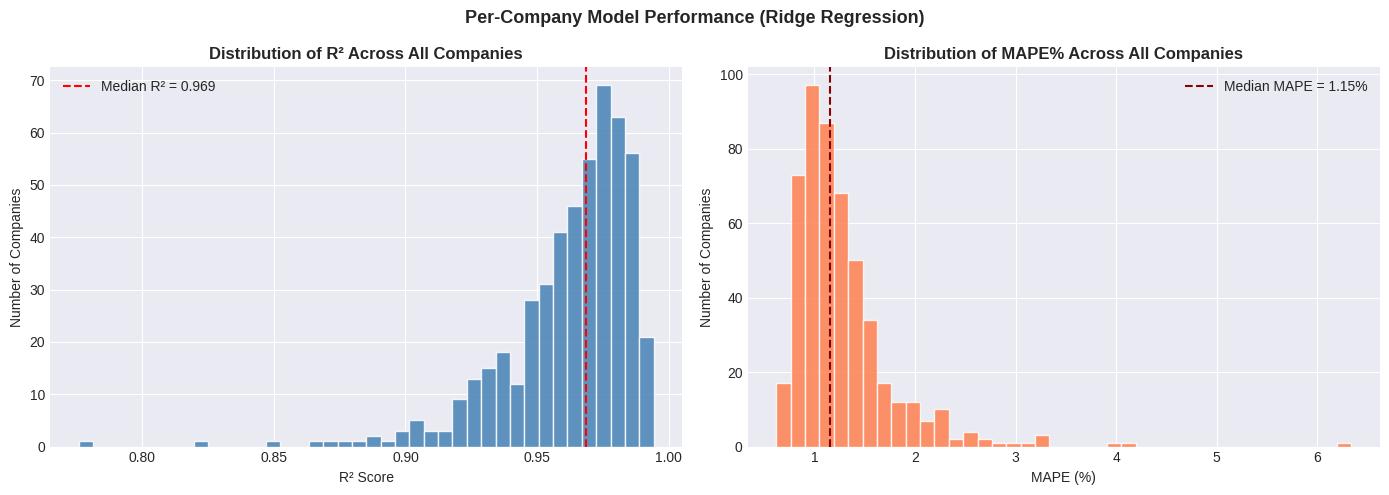

In [71]:
# Distribution of R² across all companies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Per-Company Model Performance ({best_name})',
             fontsize=13, fontweight='bold')

axes[0].hist(per_df['R²'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(per_df['R²'].median(), color='red', linestyle='--',
                label=f'Median R² = {per_df["R²"].median():.3f}')
axes[0].set_title('Distribution of R² Across All Companies', fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].set_ylabel('Number of Companies')
axes[0].legend()

axes[1].hist(per_df['MAPE%'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(per_df['MAPE%'].median(), color='darkred', linestyle='--',
                label=f'Median MAPE = {per_df["MAPE%"].median():.2f}%')
axes[1].set_title('Distribution of MAPE% Across All Companies', fontweight='bold')
axes[1].set_xlabel('MAPE (%)')
axes[1].set_ylabel('Number of Companies')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
Step 13 — Final Summary & Conclusions

In [73]:
print('=' * 65)
print('   FINAL PROJECT SUMMARY')
print('   Multi-Company Stock Price Prediction — 501 Companies')
print('=' * 65)

print(f'''
📦 Dataset
   Companies : {df_raw['symbol'].nunique()}
   Total rows: {len(df_raw):,}
   Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}
   Features  : {len(FEATURE_COLS)} engineered per company

🔧 Feature Categories
   • OHLCV base features      (4)
   • MACD                     (1)
   • Volatility               (1)
   • Price-derived features   (3)
   • Volume analytics         (2)
   • RSI                      (1)
   • Bollinger Bands         (2)
   • Rate of Change          (2)
''')

print('📊 Model Performance (Test Set):')
print(results_df.round(4).to_string())

best_r2 = results_df.loc[best_name, 'R² Score']
best_mape = results_df.loc[best_name, 'MAPE (%)']
lr_r2 = results_df.loc['Linear Regression', 'R² Score']

print(f'''
🏆 Best model : {best_name}
   R²         : {best_r2:.4f}  ({best_r2*100:.2f}% variance explained)
   MAPE       : {best_mape:.2f}%  (average error percentage)

📈 Linear Regression
   R²         : {lr_r2:.4f}

📌 Per-company analysis ({best_name})
   Median R²  : {per_df["R²"].median():.4f}
   Companies with R² > 0.95 : {(per_df["R²"] > 0.95).sum()}
   Companies with R² > 0.90 : {(per_df["R²"] > 0.90).sum()}
   Companies with R² > 0.80 : {(per_df["R²"] > 0.80).sum()}

🔑 Key Observations
   1. Engineered technical indicators strongly capture price movements
   2. Linear models (Ridge/Linear Regression) perform best due to strong linear relationships
   3. Tree-based models perform slightly lower but remain stable
   4. Volume and volatility features improve robustness of predictions
   5. RSI and MACD provide useful market momentum signals
   6. Model generalizes well across 501 companies using a single training pipeline
''')

   FINAL PROJECT SUMMARY
   Multi-Company Stock Price Prediction — 501 Companies

📦 Dataset
   Companies : 501
   Total rows: 851,264
   Date range: 2010-01-04 → 2016-12-30
   Features  : 17 engineered per company

🔧 Feature Categories
   • OHLCV base features      (4)
   • MACD                     (1)
   • Volatility               (1)
   • Price-derived features   (3)
   • Volume analytics         (2)
   • RSI                      (1)
   • Bollinger Bands         (2)
   • Rate of Change          (2)

📊 Model Performance (Test Set):
                   R² Score  MAE ($)  RMSE ($)  MAPE (%)
Model                                                   
Ridge Regression     0.9995   0.9857    2.2912    1.2770
Linear Regression    0.9995   0.9857    2.2912    1.2770
Lasso Regression     0.9995   1.0288    2.3820    1.4613
Gradient Boosting    0.9973   1.4503    5.3742    2.1253
Random Forest        0.9942   1.3010    7.8399    1.3176
Decision Tree        0.9603   1.7095   20.5118    1.4211

🏆 Be